In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('sales.csv')

In [4]:
df

,OrderID,Order Date,Customer_Name,Region,Product,Category,Quantity,Unit Price,Total Amount,Payment Method,Discount,Customer Age,Email,Country,Order Status
0,1001,2024-01-05,John Smith,North,Laptop,Electronics,1,1200,1200,Credit Card,0.0,34,johnsmith@email.com,USA,Completed
1,1002,05/01/2024,Mary Johnson,South,Phone,Electronics,2,800,1600,credit card,5.0,29,mary@email,USA,Completed
2,1003,2024/01/06,Robert Brown,east,Tablet,Electronics,1,400,400,Debit Card,NaN,45,robert@email.com,USA,Completed
3,1004,2024-01-07,Linda Davis,West,Headphones,Electronics,5,50,250,Cash,0.0,abc,linda@email.com,USA,Completed
4,1005,07-01-2024,Michael Wilson,North,Monitor,Electronics,-1,300,-300,Credit Card,10.0,38,michael@email.com,USA,Returned
5,1006,2024-01-08,Sarah Miller,South,Keyboard,Electronics,3,30,90,Credit Card,NaN,27,sarah@email.com,USA,Completed
6,1007,2024-01-08,Sarah Miller,South,Keyboard,Electronics,3,30,90,Credit Card,NaN,27,sarah@email.com,USA,Completed
7,1008,2024-01-09,David Moore,EAST,Mouse,Electronics,10,15,150,Debit Card,0.0,31,david@email.com,USA,Completed
8,1009,2024-01-10,,West,Laptop,Electronics,1,1200,1200,Credit Card,0.0,41,missing@email.com,USA,Completed
9,1010,2024-01-11,James Taylor,North,Phone,Electronics,2,$800,$1600,Credit Card,5.0,36,james@email.com,USA,Completed


In [5]:
df.head()

,OrderID,Order Date,Customer_Name,Region,Product,Category,Quantity,Unit Price,Total Amount,Payment Method,Discount,Customer Age,Email,Country,Order Status
0,1001,2024-01-05,John Smith,North,Laptop,Electronics,1,1200,1200,Credit Card,0.0,34,johnsmith@email.com,USA,Completed
1,1002,05/01/2024,Mary Johnson,South,Phone,Electronics,2,800,1600,credit card,5.0,29,mary@email,USA,Completed
2,1003,2024/01/06,Robert Brown,east,Tablet,Electronics,1,400,400,Debit Card,NaN,45,robert@email.com,USA,Completed
3,1004,2024-01-07,Linda Davis,West,Headphones,Electronics,5,50,250,Cash,0.0,abc,linda@email.com,USA,Completed
4,1005,07-01-2024,Michael Wilson,North,Monitor,Electronics,-1,300,-300,Credit Card,10.0,38,michael@email.com,USA,Returned


In [6]:
df.columns

Index(['OrderID', 'Order Date', 'Customer_Name', 'Region', 'Product',
       'Category', 'Quantity', 'Unit Price', 'Total Amount', 'Payment Method',
       'Discount', 'Customer Age', 'Email', 'Country', 'Order Status'],
      dtype='str')

In [7]:
df.shape

(50, 15)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   OrderID         50 non-null     int64  
 1   Order Date      50 non-null     str    
 2   Customer_Name   50 non-null     str    
 3   Region          50 non-null     str    
 4   Product         50 non-null     str    
 5   Category        50 non-null     str    
 6   Quantity        49 non-null     str    
 7   Unit Price      49 non-null     str    
 8   Total Amount    49 non-null     str    
 9   Payment Method  50 non-null     str    
 10  Discount        47 non-null     float64
 11  Customer Age    49 non-null     str    
 12  Email           50 non-null     str    
 13  Country         50 non-null     str    
 14  Order Status    50 non-null     str    
dtypes: float64(1), int64(1), str(13)
memory usage: 6.0 KB


In [9]:
df.describe()

,OrderID,Discount
count,50.00000,47.000000
mean,1025.50000,4.574468
std,14.57738,29.188849
min,1001.00000,-5.000000
25%,1013.25000,0.000000
50%,1025.50000,0.000000
75%,1037.75000,0.000000
max,1050.00000,200.000000


In [13]:
df.isna()

,OrderID,Order Date,Customer_Name,Region,Product,Category,Quantity,Unit Price,Total Amount,Payment Method,Discount,Customer Age,Email,Country,Order Status
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

OrderID           0
Order Date        0
Customer_Name     0
Region            0
Product           0
Category          0
Quantity          1
Unit Price        1
Total Amount      1
Payment Method    0
Discount          3
Customer Age      1
Email             0
Country           0
Order Status      0
dtype: int64

In [11]:
df.isnull().sum()

OrderID           0
Order Date        0
Customer_Name     0
Region            0
Product           0
Category          0
Quantity          1
Unit Price        1
Total Amount      1
Payment Method    0
Discount          3
Customer Age      1
Email             0
Country           0
Order Status      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for Order Date:
Order Date
2024-01-08    2
2024-01-05    1
05/01/2024    1
2024/01/06    1
2024-01-07    1
07-01-2024    1
2024-01-09    1
2024-01-10    1
2024-01-11    1
2024-01-12    1
2024-01-13    1
2024-01-14    1
2024-01-15    1
2024-01-16    1
2024-01-17    1
2024-01-18    1
2024-01-19    1
2024-01-20    1
2024-01-21    1
2024-01-22    1
2024-01-23    1
2024-01-24    1
2024-01-25    1
2024-01-26    1
2024-01-27    1
2024-01-28    1
2024/01/29    1
29-01-2024    1
2024-01-30    1
2024-01-31    1
2024-02-01    1
2024-02-02    1
2024-02-03    1
2024-02-04    1
2024-02-05    1
2024-02-06    1
2024-02-07    1
2024-02-08    1
2024-02-09    1
2024-02-10    1
2024-02-11    1
2024-02-12    1
2024-02-13    1
2024-02-14    1
2024-02-15    1
2024-02-16    1
2024-02-17    1
2024-02-18    1
2024-02-19    1
Name: count, dtype: int64

Value Counts for Customer_Name:
Customer_Name
Sarah Miller          2
                      2
John Smith            1
Mary Johnson          1
 Rober

In [15]:
# Fix numeric columns first
numeric_cols = ['Quantity', 'Unit Price', 'Total Amount', 'Discount', 'Customer Age']

# Remove $ sign if exists
df['Unit Price'] = df['Unit Price'].str.replace('$', '', regex=False)
df['Total Amount'] = df['Total Amount'].str.replace('$', '', regex=False)

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

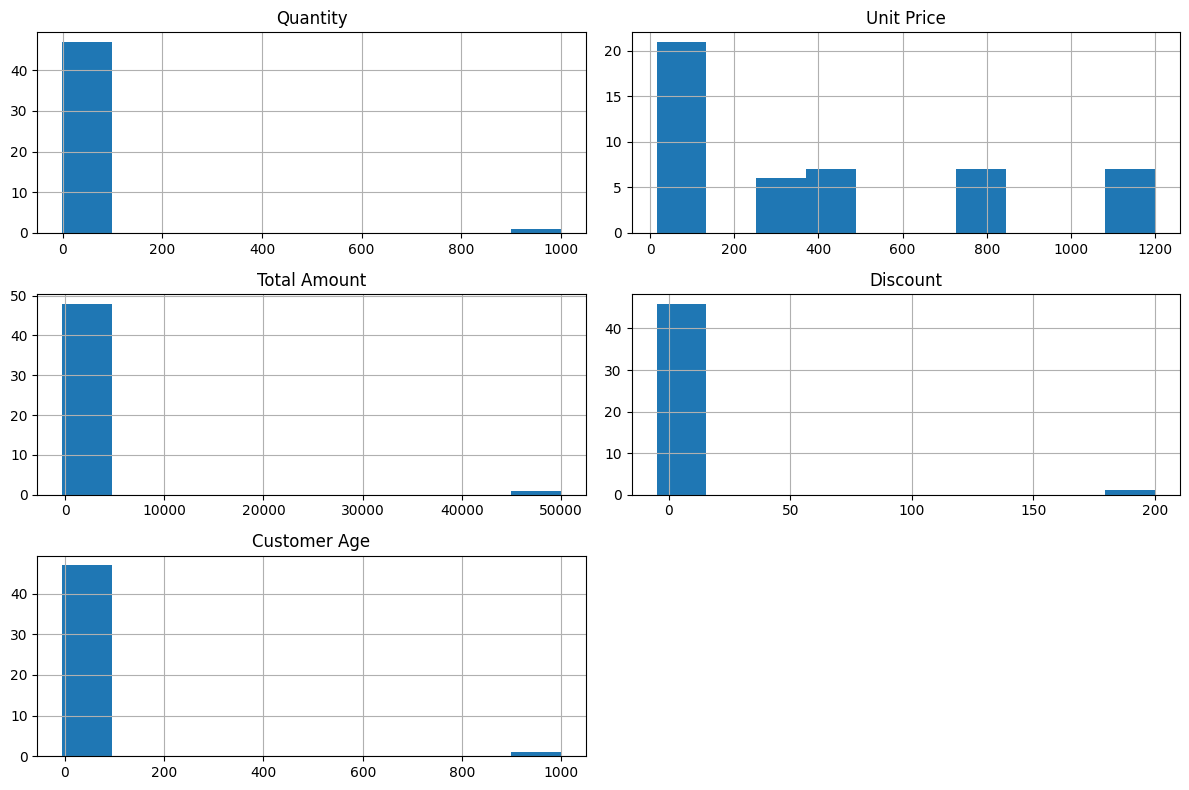

In [16]:
df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

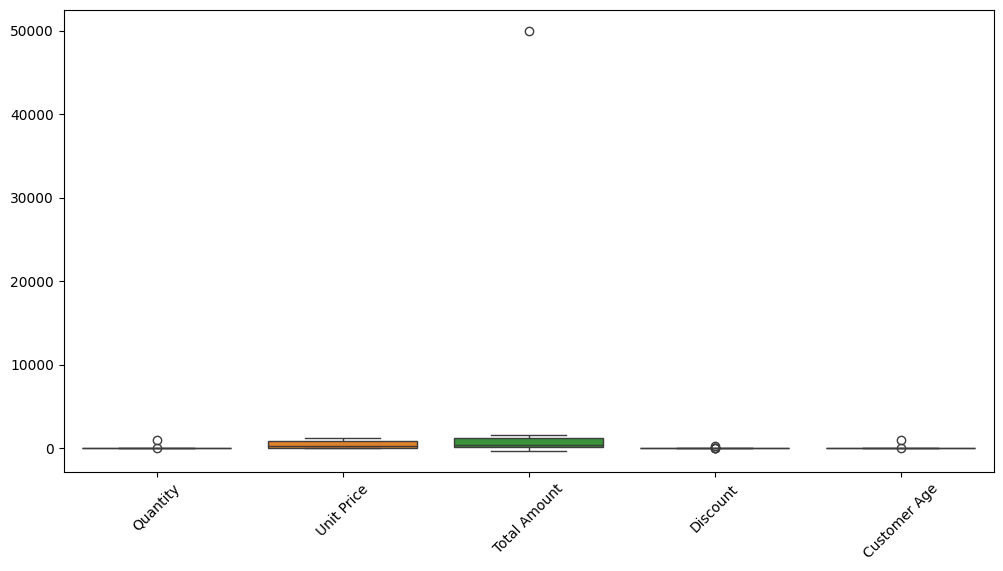

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

In [18]:
df = df.drop_duplicates()

In [19]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [20]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [25]:
df['Revenue_Per_Unit'] = df['Total Amount'] / (df['Quantity'] + 1e-5)

In [26]:
columns_to_remove = ['OrderID', 'Customer_Name', 'Email']

df = df.drop(columns=columns_to_remove, errors='ignore')

print("Final Features:")
print(df.columns)

Final Features:
Index(['Order Date', 'Region', 'Product', 'Category', 'Quantity', 'Unit Price',
       'Total Amount', 'Payment Method', 'Discount', 'Customer Age', 'Country',
       'Order Status', 'Revenue_Per_Unit'],
      dtype='str')


In [28]:
df.duplicated().sum()

np.int64(1)

In [29]:
df.isnull().sum()

Order Date          0
Region              0
Product             0
Category            0
Quantity            0
Unit Price          0
Total Amount        0
Payment Method      0
Discount            0
Customer Age        0
Country             0
Order Status        0
Revenue_Per_Unit    0
dtype: int64

In [30]:
df.describe()

,Order Date,Region,Product,Category,Quantity,Unit Price,Total Amount,Payment Method,Discount,Customer Age,Country,Order Status,Revenue_Per_Unit
count,50.000000,50.000000,50.000000,50.0,5.000000e+01,5.000000e+01,5.000000e+01,50.000000,5.000000e+01,5.000000e+01,50.000000,50.000000,50.000000
mean,23.600000,1.900000,2.960000,0.0,4.440892e-17,4.440892e-18,-5.329071e-17,1.980000,4.218847e-17,-3.552714e-17,0.980000,1.000000,0.724367
std,14.422205,0.886405,2.019901,0.0,1.010153e+00,1.010153e+00,1.010153e+00,0.552914,1.010153e+00,1.010153e+00,0.141421,0.202031,4.882609
min,0.000000,0.000000,0.000000,0.0,-2.065591e+00,-1.515229e+00,-1.997554e+00,0.000000,-3.319291e-01,-1.827912e+00,0.000000,0.000000,-9.351988
25%,11.250000,1.000000,1.000000,0.0,-1.204928e+00,-1.010153e+00,-8.049845e-01,2.000000,-1.534726e-01,-8.884014e-01,1.000000,1.000000,-0.074231
50%,23.500000,2.000000,3.000000,0.0,8.606630e-02,0.000000e+00,8.944272e-02,2.000000,-1.534726e-01,-2.405148e-02,1.000000,1.000000,0.840766
75%,35.750000,3.000000,5.000000,0.0,5.163978e-01,1.010153e+00,9.838699e-01,2.000000,-1.534726e-01,6.899768e-01,1.000000,1.000000,2.482558
max,48.000000,3.000000,6.000000,0.0,1.807392e+00,1.515229e+00,1.282012e+00,3.000000,6.984788e+00,2.080453e+00,1.000000,2.000000,14.893906


In [31]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.shape

(49, 13)

In [35]:
df.isnull().sum()

Order Date          0
Region              0
Product             0
Category            0
Quantity            0
Unit Price          0
Total Amount        0
Payment Method      0
Discount            0
Customer Age        0
Country             0
Order Status        0
Revenue_Per_Unit    0
dtype: int64

In [36]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order Date        49 non-null     datetime64[ns]
 1   Region            49 non-null     int64         
 2   Product           49 non-null     int64         
 3   Category          49 non-null     int64         
 4   Quantity          49 non-null     float64       
 5   Unit Price        49 non-null     float64       
 6   Total Amount      49 non-null     float64       
 7   Payment Method    49 non-null     int64         
 8   Discount          49 non-null     float64       
 9   Customer Age      49 non-null     float64       
 10  Country           49 non-null     int64         
 11  Order Status      49 non-null     int64         
 12  Revenue_Per_Unit  49 non-null     float64       
 13  Year              49 non-null     int32         
 14  Month             49 non-null     int32     

In [41]:
df.drop('Order Date', axis=1, inplace=True)

In [43]:
print(df.columns)

Index(['Region', 'Product', 'Category', 'Quantity', 'Unit Price',
       'Total Amount', 'Payment Method', 'Discount', 'Customer Age', 'Country',
       'Order Status', 'Revenue_Per_Unit', 'Year', 'Month', 'Day'],
      dtype='str')


In [44]:
'Order Date' in df.columns

False

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 49
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Region            49 non-null     int64  
 1   Product           49 non-null     int64  
 2   Category          49 non-null     int64  
 3   Quantity          49 non-null     float64
 4   Unit Price        49 non-null     float64
 5   Total Amount      49 non-null     float64
 6   Payment Method    49 non-null     int64  
 7   Discount          49 non-null     float64
 8   Customer Age      49 non-null     float64
 9   Country           49 non-null     int64  
 10  Order Status      49 non-null     int64  
 11  Revenue_Per_Unit  49 non-null     float64
 12  Year              49 non-null     int32  
 13  Month             49 non-null     int32  
 14  Day               49 non-null     int32  
dtypes: float64(6), int32(3), int64(6)
memory usage: 5.6 KB


In [47]:
df['Order Date'] = pd.to_datetime(
    df[['Year', 'Month', 'Day']]
)

df.drop(['Year', 'Month', 'Day'], axis=1, inplace=True)

In [49]:
df.to_csv("cleaned_ml_dataset.csv", index=False)